In [ ]:
!pip install transformers torchaudio -q
!pip install psutil

import os
import sys
import time
import random
import torch
import torchaudio
import numpy as np
import pandas as pd
import psutil

import torch.nn as nn
import torch.nn.functional as F

from transformers import Wav2Vec2ForSequenceClassification
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import WavLMForSequenceClassification
from google.colab import drive

In [ ]:
drive.mount("/content/drive")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

TEST_DIR = "/content/drive/MyDrive/dataset_split/test"
OUTPUT_DIR = "/content/drive/MyDrive/final_model_comparison"

os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATHS = {
    "wavlm": "/content/best_wavlm_model.pt",
    "rawnet3": "/content/best_rawnet_model.pt",
    "aasist": "/content/best_aasist_official.pt",
    "wav2vec2": "/content/best_model_wav2vec2.pt"

}

for name, path in MODEL_PATHS.items():
    print(name, os.path.exists(path), path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
wavlm True /content/best_wavlm_model.pt
rawnet3 True /content/best_rawnet_model.pt
aasist True /content/best_aasist_official.pt
wav2vec2 True /content/best_model_wav2vec2.pt


In [ ]:
class DeepfakeAudioDataset(Dataset):
    def __init__(self, root_dir, target_sample_rate=16000, max_duration=4):
        self.samples = []
        self.target_sample_rate = target_sample_rate
        self.max_length = target_sample_rate * max_duration
        self.valid_exts = (".wav", ".mp3", ".flac", ".m4a")

        real_dir = os.path.join(root_dir, "real")
        if os.path.exists(real_dir):
            for file in os.listdir(real_dir):
                if file.lower().endswith(self.valid_exts):
                    self.samples.append({
                        "path": os.path.join(real_dir, file),
                        "label": 0,
                        "attack_type": "real"
                    })

        fake_dir = os.path.join(root_dir, "fake")
        if os.path.exists(fake_dir):
            for attack_folder in os.listdir(fake_dir):
                attack_path = os.path.join(fake_dir, attack_folder)

                if os.path.isdir(attack_path):
                    for subdir, _, files_list in os.walk(attack_path):
                        for file in files_list:
                            if file.lower().endswith(self.valid_exts):
                                self.samples.append({
                                    "path": os.path.join(subdir, file),
                                    "label": 1,
                                    "attack_type": attack_folder
                                })

        print("Loaded files:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def _load_audio(self, filepath):
        waveform, sr = torchaudio.load(filepath)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(sr, self.target_sample_rate)
            waveform = resampler(waveform)

        return waveform.squeeze(0)

    def _crop_or_pad(self, waveform):
        length = waveform.shape[0]

        if length > self.max_length:
            start = (length - self.max_length) // 2
            waveform = waveform[start:start + self.max_length]
            attention_mask = torch.ones(self.max_length, dtype=torch.long)
        else:
            pad_len = self.max_length - length
            waveform = F.pad(waveform, (0, pad_len))
            attention_mask = torch.cat([
                torch.ones(length, dtype=torch.long),
                torch.zeros(pad_len, dtype=torch.long)
            ])

        return waveform, attention_mask

    def __getitem__(self, idx):
        sample = self.samples[idx]

        waveform = self._load_audio(sample["path"])
        waveform, attention_mask = self._crop_or_pad(waveform)

        return {
            "input_values": waveform,
            "attention_mask": attention_mask,
            "labels": torch.tensor(sample["label"], dtype=torch.long),
            "path": sample["path"],
            "attack_type": sample["attack_type"]
        }

In [ ]:
# ==========================================
# 1. Dataset - RawNet3-style
# ==========================================

class DeepfakeAudioDatasetRawNet(Dataset):
    def __init__(self, root_dir, target_sample_rate=16000, max_duration=4, mode='train'):
        self.samples = []
        self.target_sample_rate = target_sample_rate
        self.max_length = target_sample_rate * max_duration
        self.mode = mode
        self.valid_exts = ('.wav', '.mp3', '.flac', '.m4a')

        # real = 0
        real_dir = os.path.join(root_dir, 'real')
        if os.path.exists(real_dir):
            for file in os.listdir(real_dir):
                if file.lower().endswith(self.valid_exts):
                    self.samples.append({
                        "path": os.path.join(real_dir, file),
                        "label": 0,
                        "attack_type": "real"
                    })

        # fake = 1
        fake_dir = os.path.join(root_dir, 'fake')
        if os.path.exists(fake_dir):
            for attack_folder in os.listdir(fake_dir):
                attack_path = os.path.join(fake_dir, attack_folder)

                if os.path.isdir(attack_path):
                    for subdir, _, files in os.walk(attack_path):
                        for file in files:
                            if file.lower().endswith(self.valid_exts):
                                self.samples.append({
                                    "path": os.path.join(subdir, file),
                                    "label": 1,
                                    "attack_type": attack_folder
                                })

        self.filepaths = [s["path"] for s in self.samples]
        self.labels = [s["label"] for s in self.samples]
        self.attack_types = [s["attack_type"] for s in self.samples]

        print(f"[{mode}] Loaded {len(self.samples)} files from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def _load_audio(self, filepath):
        waveform, sample_rate = torchaudio.load(filepath)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sample_rate != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(
                orig_freq=sample_rate,
                new_freq=self.target_sample_rate
            )
            waveform = resampler(waveform)

        return waveform.squeeze(0)

    def _crop_or_pad(self, waveform):
        length = waveform.shape[0]

        if length > self.max_length:
            if self.mode == 'train':
                start = random.randint(0, length - self.max_length)
            else:
                start = (length - self.max_length) // 2

            waveform = waveform[start:start + self.max_length]

        else:
            pad_length = self.max_length - length
            waveform = F.pad(waveform, (0, pad_length))

        return waveform

    def __getitem__(self, idx):
        sample = self.samples[idx]

        waveform = self._load_audio(sample["path"])
        waveform = self._crop_or_pad(waveform)

        return {
            "input_values": waveform,
            "labels": torch.tensor(sample["label"], dtype=torch.long),

            # לדוחות
            "path": sample["path"],
            "attack_type": sample["attack_type"]
        }

In [ ]:
test_dataset = DeepfakeAudioDataset(TEST_DIR)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

rawnet_test_dataset = DeepfakeAudioDatasetRawNet(
    root_dir=TEST_DIR,
    target_sample_rate=16000,
    max_duration=4,
    mode="test"
)

rawnet_test_loader = DataLoader(
    rawnet_test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Loaded files: 2661
[test] Loaded 2661 files from /content/drive/MyDrive/dataset_split/test


In [ ]:
class DeepfakeAudioDatasetAASIST(Dataset):
    def __init__(self, root_dir, nb_samp=64600, target_sample_rate=16000, mode="test"):
        self.samples = []
        self.nb_samp = nb_samp
        self.target_sample_rate = target_sample_rate
        self.mode = mode
        self.valid_exts = (".wav", ".mp3", ".flac", ".m4a")

        real_dir = os.path.join(root_dir, "real")
        if os.path.exists(real_dir):
            for file in os.listdir(real_dir):
                if file.lower().endswith(self.valid_exts):
                    self.samples.append({
                        "path": os.path.join(real_dir, file),
                        "label": 0,
                        "attack_type": "real"
                    })

        fake_dir = os.path.join(root_dir, "fake")
        if os.path.exists(fake_dir):
            for attack_folder in os.listdir(fake_dir):
                attack_path = os.path.join(fake_dir, attack_folder)

                if os.path.isdir(attack_path):
                    for subdir, _, files_list in os.walk(attack_path):
                        for file in files_list:
                            if file.lower().endswith(self.valid_exts):
                                self.samples.append({
                                    "path": os.path.join(subdir, file),
                                    "label": 1,
                                    "attack_type": attack_folder
                                })

        print("[AASIST] Loaded files:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def _load_audio(self, filepath):
        waveform, sr = torchaudio.load(filepath)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(sr, self.target_sample_rate)
            waveform = resampler(waveform)

        return waveform.squeeze(0)

    def _crop_or_pad(self, waveform):
        length = waveform.shape[0]

        if length > self.nb_samp:
            start = (length - self.nb_samp) // 2
            waveform = waveform[start:start + self.nb_samp]
        else:
            pad_len = self.nb_samp - length
            waveform = F.pad(waveform, (0, pad_len))

        return waveform

    def __getitem__(self, idx):
        sample = self.samples[idx]

        waveform = self._load_audio(sample["path"])
        waveform = self._crop_or_pad(waveform)

        return {
            "input_values": waveform,
            "labels": torch.tensor(sample["label"], dtype=torch.long),
            "path": sample["path"],
            "attack_type": sample["attack_type"]
        }

In [ ]:
aasist_test_dataset = DeepfakeAudioDatasetAASIST(
    root_dir=TEST_DIR,
    nb_samp=64600,
    target_sample_rate=16000,
    mode="test"
)

aasist_test_loader = DataLoader(
    aasist_test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

[AASIST] Loaded files: 2661


In [ ]:
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        hidden = max(1, channels // reduction)

        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        # x: [B, C, T]
        s = x.mean(dim=-1)
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        s = s.unsqueeze(-1)

        return x * s


class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dilation=1):
        super().__init__()

        padding = dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=3,
            stride=stride,
            padding=padding,
            dilation=dilation,
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=3,
            stride=1,
            padding=padding,
            dilation=dilation,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.se = SEBlock1D(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.act = nn.LeakyReLU(0.1)

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)

        out = out + residual
        out = self.act(out)

        return out


class AttentiveStatsPool1D(nn.Module):
    def __init__(self, in_channels, attention_hidden=128):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Conv1d(in_channels, attention_hidden, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(attention_hidden, in_channels, kernel_size=1)
        )

    def forward(self, x, mask=None):
        attention_scores = self.attention(x)

        if mask is not None:
            mask = mask.unsqueeze(1)
            attention_scores = attention_scores.masked_fill(mask == 0, -1e9)

        weights = torch.softmax(attention_scores, dim=-1)

        mean = torch.sum(weights * x, dim=-1)
        std = torch.sqrt(
            torch.sum(weights * (x - mean.unsqueeze(-1)) ** 2, dim=-1).clamp(min=1e-9)
        )

        return torch.cat([mean, std], dim=1)


class RawNetBinary(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.frontend = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, stride=3, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
        )

        self.block1 = ResidualBlock1D(64, 64, stride=1, dilation=1)
        self.block2 = ResidualBlock1D(64, 128, stride=2, dilation=1)
        self.block3 = ResidualBlock1D(128, 128, stride=1, dilation=2)
        self.block4 = ResidualBlock1D(128, 256, stride=2, dilation=2)
        self.block5 = ResidualBlock1D(256, 256, stride=1, dilation=3)
        self.block6 = ResidualBlock1D(256, 256, stride=2, dilation=3)

        self.pool = AttentiveStatsPool1D(256, attention_hidden=128)

        self.embedding = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Linear(256, num_classes)

    def downsample_mask(self, mask, target_len):
        if mask is None:
            return None

        mask = mask.float().unsqueeze(1)
        mask = F.interpolate(mask, size=target_len, mode="nearest")
        mask = mask.squeeze(1).long()

        return mask

    def forward(self, input_values, attention_mask=None, labels=None):
      x = input_values.unsqueeze(1)

      x = self.frontend(x)
      x = self.block1(x)
      x = self.block2(x)
      x = self.block3(x)
      x = self.block4(x)
      x = self.block5(x)
      x = self.block6(x)

      pooled_mask = self.downsample_mask(attention_mask, x.shape[-1]) if attention_mask is not None else None

      x = self.pool(x, pooled_mask)
      x = self.embedding(x)
      logits = self.classifier(x)

      if labels is not None:
        loss = F.cross_entropy(logits, labels)
        return {"loss": loss, "logits": logits}

      return {"logits": logits}

In [ ]:
# אם אין לך את תיקיית aasist כבר ב-Colab, תריצי:
if not os.path.exists("/content/aasist"):
    !git clone https://github.com/clovaai/aasist.git /content/aasist

sys.path.append("/content/aasist")

from models.AASIST import Model

aasist_config = {
    "architecture": "AASIST",
    "nb_samp": 64600,
    "first_conv": 128,
    "filts": [
        70,
        [1, 32],
        [32, 32],
        [32, 64],
        [64, 64]
    ],
    "gat_dims": [64, 32],
    "pool_ratios": [
        0.5,
        0.7,
        0.5,
        0.5
    ],
    "temperatures": [
        2.0,
        2.0,
        100.0,
        100.0
    ]
}

In [ ]:
def extract_logits(outputs):
    # HuggingFace models
    if hasattr(outputs, "logits"):
        return outputs.logits

    # Dict models
    if isinstance(outputs, dict):
        return outputs["logits"]

    # AASIST often returns tuple: (embedding, logits)
    if isinstance(outputs, (tuple, list)):
        for item in outputs:
            if torch.is_tensor(item) and item.dim() == 2 and item.shape[1] == 2:
                return item

    # Direct logits
    if torch.is_tensor(outputs):
        return outputs

    raise ValueError("Could not extract logits from model output")


def evaluate_model_full_report(
    model,
    model_name,
    model_path,
    test_loader,
    device,
    output_dir,
    model_type
):
    model.to(device)
    model.eval()

    process = psutil.Process(os.getpid())

    ram_before_mb = process.memory_info().rss / (1024 ** 2)

    if torch.cuda.is_available():
      torch.cuda.reset_peak_memory_stats()

    rows = []
    inference_times = []
    token_counts = []
    frame_counts = []

    # שימוש ב-os
    model_file_size_mb = os.path.getsize(model_path) / (1024 ** 2)

    num_parameters = sum(p.numel() for p in model.parameters())

    memory_size_mb = sum(
        p.numel() * p.element_size()
        for p in model.parameters()
    ) / (1024 ** 2)

    with torch.no_grad():
        for batch in test_loader:
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)

            attention_mask = batch.get("attention_mask", None)
            if attention_mask is not None:
                attention_mask = attention_mask.to(device)

            start_time = time.time()

            if model_type == "transformer":
                outputs = model(
                    input_values=input_values,
                    attention_mask=attention_mask
                )
            else:
                try:
                    outputs = model(
                        input_values=input_values,
                        attention_mask=attention_mask
                    )
                except TypeError:
                    outputs = model(input_values)

            end_time = time.time()

            inference_times.append(end_time - start_time)

            logits = extract_logits(outputs)

            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)

            # Tokens / Frames
            if model_name == "wavlm":
                try:
                    hidden = model.wavlm(
                        input_values=input_values,
                        attention_mask=attention_mask
                    ).last_hidden_state
                    token_counts.append(hidden.shape[1])
                except:
                    pass

            elif model_name == "rawnet3":
                # RawNet לא עובד עם tokens כמו Transformer
                # אבל אפשר למדוד כמה frames נשארים אחרי ה-frontend+blocks
                try:
                    x = input_values.unsqueeze(1)
                    x = model.frontend(x)
                    x = model.block1(x)
                    x = model.block2(x)
                    x = model.block3(x)
                    x = model.block4(x)
                    x = model.block5(x)
                    x = model.block6(x)
                    frame_counts.append(x.shape[-1])
                except:
                    pass

            elif model_name == "aasist":
                # AASIST לא מחזיר tokens בצורה פשוטה כמו WavLM
                # לכן נשמור Not applicable
                pass

            for i in range(len(labels)):
                path = batch["path"][i]
                recording_id = os.path.splitext(os.path.basename(path))[0]

                rows.append({
                    "model_name": model_name,
                    "recording_id": recording_id,
                    "path": path,
                    "attack_type": batch["attack_type"][i],
                    "true_label": int(labels[i].cpu().item()),
                    "pred_label": int(preds[i].cpu().item()),
                    "prob_fake": float(probs[i].cpu().item()),
                    "is_correct": int(labels[i].cpu().item()) == int(preds[i].cpu().item())
                })

    ram_after_mb = process.memory_info().rss / (1024 ** 2)
    ram_used_mb = ram_after_mb - ram_before_mb

    if torch.cuda.is_available():
      peak_gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
      peak_gpu_memory_mb = 0

    predictions_df = pd.DataFrame(rows)
    failed_df = predictions_df[predictions_df["is_correct"] == False].copy()

    avg_batch_time = np.mean(inference_times)
    avg_file_time = avg_batch_time / test_loader.batch_size

    if len(token_counts) > 0:
        tokens_or_frames = round(np.mean(token_counts), 2)
        representation_type = "Transformer tokens"
    elif len(frame_counts) > 0:
        tokens_or_frames = round(np.mean(frame_counts), 2)
        representation_type = "CNN frames after feature extraction"
    else:
        tokens_or_frames = "Not applicable"
        representation_type = "No explicit tokenization"

    efficiency_df = pd.DataFrame([{
        "model_name": model_name,
        "model_file_size_MB_os": round(model_file_size_mb, 2),
        "num_parameters": num_parameters,
        "memory_size_MB": round(memory_size_mb, 2),
        "ram_before_MB": round(ram_before_mb, 2),
        "ram_after_MB": round(ram_after_mb, 2),
        "ram_used_MB": round(ram_used_mb, 2),
        "peak_gpu_memory_MB": round(peak_gpu_memory_mb, 2),
        "avg_inference_time_per_batch_sec": round(avg_batch_time, 4),
        "avg_inference_time_per_file_sec": round(avg_file_time, 4),
        "tokens_or_frames": tokens_or_frames,
        "representation_type": representation_type,
        "batch_size": test_loader.batch_size,
        "total_test_files": len(predictions_df),
        "failed_files": len(failed_df)
    }])

    predictions_path = os.path.join(output_dir, f"{model_name}_predictions_per_file.csv")
    failed_path = os.path.join(output_dir, f"{model_name}_failed_recordings.csv")
    efficiency_path = os.path.join(output_dir, f"{model_name}_efficiency_report.csv")

    predictions_df.to_csv(predictions_path, index=False)
    failed_df.to_csv(failed_path, index=False)
    efficiency_df.to_csv(efficiency_path, index=False)

    print(f"\n=== {model_name} DONE ===")
    print("Predictions:", predictions_path)
    print("Failed recordings:", failed_path)
    print("Efficiency:", efficiency_path)

    display(efficiency_df)
    display(failed_df.head())

    return predictions_df, failed_df, efficiency_df

In [ ]:
wavlm_model = WavLMForSequenceClassification.from_pretrained(
    "microsoft/wavlm-base",
    num_labels=2
)

wavlm_model.load_state_dict(
    torch.load(MODEL_PATHS["wavlm"], map_location=DEVICE)
)

wavlm_predictions, wavlm_failed, wavlm_efficiency = evaluate_model_full_report(
    model=wavlm_model,
    model_name="wavlm",
    model_path=MODEL_PATHS["wavlm"],
    test_loader=test_loader,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    model_type="transformer"
)

import gc

del wavlm_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base
Key               | Status  | 
------------------+---------+-
projector.bias    | MISSING | 
projector.weight  | MISSING | 
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



=== wavlm DONE ===
Predictions: /content/drive/MyDrive/final_model_comparison/wavlm_predictions_per_file.csv
Failed recordings: /content/drive/MyDrive/final_model_comparison/wavlm_failed_recordings.csv
Efficiency: /content/drive/MyDrive/final_model_comparison/wavlm_efficiency_report.csv


,model_name,model_file_size_MB_os,num_parameters,memory_size_MB,ram_before_MB,ram_after_MB,ram_used_MB,peak_gpu_memory_MB,avg_inference_time_per_batch_sec,avg_inference_time_per_file_sec,tokens_or_frames,representation_type,batch_size,total_test_files,failed_files
0,wavlm,360.89,94579314,360.79,1062.89,1626.73,563.84,679.73,0.1075,0.0269,199.0,Transformer tokens,4,2661,16


,model_name,recording_id,path,attack_type,true_label,pred_label,prob_fake,is_correct
356,wavlm,DF_E_2212136,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.993424,False
908,wavlm,common_voice_he_39541220,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.999939,False
1517,wavlm,DF_E_2345821,/content/drive/MyDrive/dataset_split/test/fake...,unknown,1,0,0.003844,False
1687,wavlm,DF_E_2110929,/content/drive/MyDrive/dataset_split/test/fake...,waveform_concatenation,1,0,0.432972,False
2017,wavlm,DF_E_2676965,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.008271,False


In [ ]:
wav2vec2_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=2
)

wav2vec2_model.load_state_dict(
    torch.load(MODEL_PATHS["wav2vec2"], map_location=DEVICE)
)

wav2vec2_model.to(DEVICE)
wav2vec2_model.eval()

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
wav2vec2_predictions, wav2vec2_failed, wav2vec2_efficiency = evaluate_model_full_report(
    model=wav2vec2_model,
    model_name="wav2vec2",
    model_path=MODEL_PATHS["wav2vec2"],
    test_loader=test_loader,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    model_type="transformer"
)

del wav2vec2_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


=== wav2vec2 DONE ===
Predictions: /content/drive/MyDrive/final_model_comparison/wav2vec2_predictions_per_file.csv
Failed recordings: /content/drive/MyDrive/final_model_comparison/wav2vec2_failed_recordings.csv
Efficiency: /content/drive/MyDrive/final_model_comparison/wav2vec2_efficiency_report.csv


,model_name,model_file_size_MB_os,num_parameters,memory_size_MB,ram_before_MB,ram_after_MB,ram_used_MB,peak_gpu_memory_MB,avg_inference_time_per_batch_sec,avg_inference_time_per_file_sec,tokens_or_frames,representation_type,batch_size,total_test_files,failed_files
0,wav2vec2,360.84,94569090,360.75,1651.5,1711.27,59.77,677.18,0.1163,0.0291,Not applicable,No explicit tokenization,4,2661,20


,model_name,recording_id,path,attack_type,true_label,pred_label,prob_fake,is_correct
41,wav2vec2,DF_E_2368180,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.685154,False
195,wav2vec2,DF_E_2528966,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.975703,False
529,wav2vec2,DF_E_2641962,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.673144,False
543,wav2vec2,DF_E_2127922,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.999283,False
546,wav2vec2,DF_E_2209563,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.998651,False


In [ ]:
rawnet3_model = RawNetBinary(num_classes=2)

rawnet3_model.load_state_dict(
    torch.load(MODEL_PATHS["rawnet3"], map_location=DEVICE)
)

rawnet3_model.to(DEVICE)
rawnet3_model.eval()


RawNetBinary(
  (frontend): Sequential(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(3,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
  )
  (block1): ResidualBlock1D(
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (se): SEBlock1D(
      (fc1): Linear(in_features=64, out_features=8, bias=True)
      (fc2): Linear(in_features=8, out_features=64, bias=True)
    )
    (shortcut): Identity()
    (act): LeakyReLU(negative_slope=0.1)
  )
  (block2): ResidualBlock1D(
    (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
    (bn1): BatchNorm1d(128,

In [ ]:
rawnet3_predictions, rawnet3_failed, rawnet3_efficiency = evaluate_model_full_report(
    model=rawnet3_model,
    model_name="rawnet3",
    model_path=MODEL_PATHS["rawnet3"],
    test_loader=rawnet_test_loader,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    model_type="raw"
)

del rawnet3_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


=== rawnet3 DONE ===
Predictions: /content/drive/MyDrive/final_model_comparison/rawnet3_predictions_per_file.csv
Failed recordings: /content/drive/MyDrive/final_model_comparison/rawnet3_failed_recordings.csv
Efficiency: /content/drive/MyDrive/final_model_comparison/rawnet3_efficiency_report.csv


,model_name,model_file_size_MB_os,num_parameters,memory_size_MB,ram_before_MB,ram_after_MB,ram_used_MB,peak_gpu_memory_MB,avg_inference_time_per_batch_sec,avg_inference_time_per_file_sec,tokens_or_frames,representation_type,batch_size,total_test_files,failed_files
0,rawnet3,6.36,1648522,6.29,1722.93,1808.31,85.38,609.38,0.0083,0.001,2667.0,CNN frames after feature extraction,8,2661,900


,model_name,recording_id,path,attack_type,true_label,pred_label,prob_fake,is_correct
5,rawnet3,DF_E_2245870,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.519303,False
6,rawnet3,DF_E_2427888,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.538530,False
15,rawnet3,DF_E_2376408,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.528774,False
25,rawnet3,DF_E_2218641,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.597987,False
30,rawnet3,DF_E_2431712,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.600276,False


In [ ]:
aasist_model = Model(aasist_config)

aasist_model.load_state_dict(
    torch.load(MODEL_PATHS["aasist"], map_location=DEVICE)
)

aasist_predictions, aasist_failed, aasist_efficiency = evaluate_model_full_report(
    model=aasist_model,
    model_name="aasist",
    model_path=MODEL_PATHS["aasist"],
    test_loader=aasist_test_loader,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    model_type="raw"
)

del aasist_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


=== aasist DONE ===
Predictions: /content/drive/MyDrive/final_model_comparison/aasist_predictions_per_file.csv
Failed recordings: /content/drive/MyDrive/final_model_comparison/aasist_failed_recordings.csv
Efficiency: /content/drive/MyDrive/final_model_comparison/aasist_efficiency_report.csv


,model_name,model_file_size_MB_os,num_parameters,memory_size_MB,ram_before_MB,ram_after_MB,ram_used_MB,peak_gpu_memory_MB,avg_inference_time_per_batch_sec,avg_inference_time_per_file_sec,tokens_or_frames,representation_type,batch_size,total_test_files,failed_files
0,aasist,1.22,297866,1.14,1810.68,1939.45,128.77,1111.24,0.0193,0.0048,Not applicable,No explicit tokenization,4,2661,285


,model_name,recording_id,path,attack_type,true_label,pred_label,prob_fake,is_correct
5,aasist,DF_E_2245870,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.736032,False
10,aasist,DF_E_2559478,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.552480,False
15,aasist,DF_E_2376408,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.620757,False
17,aasist,DF_E_2458206,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.720078,False
23,aasist,DF_E_2081453,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.865849,False


In [ ]:
efficiency_files = [
    os.path.join(OUTPUT_DIR, f)
    for f in os.listdir(OUTPUT_DIR)
    if f.endswith("_efficiency_report.csv")
]

efficiency_comparison = pd.concat(
    [pd.read_csv(f) for f in efficiency_files],
    ignore_index=True
)

efficiency_comparison_path = os.path.join(
    OUTPUT_DIR,
    "all_models_efficiency_comparison.csv"
)

efficiency_comparison.to_csv(efficiency_comparison_path, index=False)

display(efficiency_comparison)
print("Saved:", efficiency_comparison_path)

,model_name,model_file_size_MB_os,num_parameters,memory_size_MB,ram_before_MB,ram_after_MB,ram_used_MB,peak_gpu_memory_MB,avg_inference_time_per_batch_sec,avg_inference_time_per_file_sec,tokens_or_frames,representation_type,batch_size,total_test_files,failed_files
0,wavlm,360.89,94579314,360.79,1062.89,1626.73,563.84,679.73,0.1075,0.0269,199.0,Transformer tokens,4,2661,16
1,wav2vec2,360.84,94569090,360.75,1651.50,1711.27,59.77,677.18,0.1163,0.0291,Not applicable,No explicit tokenization,4,2661,20
2,rawnet3,6.36,1648522,6.29,1722.93,1808.31,85.38,609.38,0.0083,0.0010,2667.0,CNN frames after feature extraction,8,2661,900
3,aasist,1.22,297866,1.14,1810.68,1939.45,128.77,1111.24,0.0193,0.0048,Not applicable,No explicit tokenization,4,2661,285


Saved: /content/drive/MyDrive/final_model_comparison/all_models_efficiency_comparison.csv


In [ ]:
prediction_files = [
    os.path.join(OUTPUT_DIR, f)
    for f in os.listdir(OUTPUT_DIR)
    if f.endswith("_predictions_per_file.csv")
]

merged = None

for file in prediction_files:
    df = pd.read_csv(file)
    model_name = df["model_name"].iloc[0]

    temp = df[[
        "recording_id",
        "attack_type",
        "true_label",
        "pred_label",
        "prob_fake",
        "is_correct"
    ]].copy()

    temp = temp.rename(columns={
        "pred_label": f"pred_{model_name}",
        "prob_fake": f"prob_{model_name}",
        "is_correct": f"correct_{model_name}"
    })

    if merged is None:
        merged = temp
    else:
        merged = merged.merge(
            temp,
            on=["recording_id", "attack_type", "true_label"],
            how="inner"
        )

correct_cols = [
    col for col in merged.columns
    if col.startswith("correct_")
]

merged["num_failed_models"] = len(correct_cols) - merged[correct_cols].sum(axis=1)

hard_cases = merged.sort_values(
    "num_failed_models",
    ascending=False
)

failure_comparison_path = os.path.join(
    OUTPUT_DIR,
    "all_models_failure_comparison.csv"
)

hard_cases.to_csv(failure_comparison_path, index=False)

display(hard_cases.head(30))
print("Saved:", failure_comparison_path)

,recording_id,attack_type,true_label,pred_wavlm,prob_wavlm,correct_wavlm,pred_wav2vec2,prob_wav2vec2,correct_wav2vec2,pred_rawnet3,prob_rawnet3,correct_rawnet3,pred_aasist,prob_aasist,correct_aasist,num_failed_models
2385,DF_E_2169262,traditional_vocoder,1,0,0.006708,False,0,0.013566,False,0,0.310127,False,1,0.991358,True,3
2506,fake_common_voice_he_41616916,elevenlabs_fake,1,0,0.063724,False,1,0.728877,True,0,0.258219,False,0,0.013814,False,3
2045,DF_E_2742866,neural_vocoder_autoregressive,1,0,0.000440,False,0,0.002373,False,0,0.488054,False,1,0.901885,True,3
908,common_voice_he_39541220,real,0,1,0.999939,False,1,0.866743,False,0,0.332212,True,1,0.793182,False,3
2017,DF_E_2676965,neural_vocoder_autoregressive,1,0,0.008271,False,0,0.237332,False,0,0.072506,False,1,0.967129,True,3
2251,DF_E_2527373,traditional_vocoder,1,0,0.004639,False,0,0.001649,False,0,0.090092,False,1,0.919970,True,3
2153,DF_E_2232060,neural_vocoder_autoregressive,1,1,0.999927,True,1,0.999595,True,0,0.277744,False,0,0.181700,False,2
1764,DF_E_2227325,waveform_concatenation,1,1,0.999932,True,1,0.999691,True,0,0.338939,False,0,0.343648,False,2
143,DF_E_2447382,real,0,0,0.000097,True,0,0.000275,True,1,0.626699,False,1,0.831201,False,2
803,common_voice_he_38131033,real,0,0,0.000088,True,0,0.000294,True,1,0.772690,False,1,0.748592,False,2


Saved: /content/drive/MyDrive/final_model_comparison/all_models_failure_comparison.csv


In [ ]:
# ==========================================
# בדיקת הקלטות משותפות שכל המודלים נכשלו בהן
# ==========================================

prediction_files = [
    os.path.join(OUTPUT_DIR, f)
    for f in os.listdir(OUTPUT_DIR)
    if f.endswith("_predictions_per_file.csv")
]

merged = None

for file in prediction_files:
    df = pd.read_csv(file)
    model_name = df["model_name"].iloc[0]

    temp = df[[
        "recording_id",
        "attack_type",
        "true_label",
        "pred_label",
        "prob_fake",
        "is_correct"
    ]].copy()

    temp = temp.rename(columns={
        "pred_label": f"pred_{model_name}",
        "prob_fake": f"prob_{model_name}",
        "is_correct": f"correct_{model_name}"
    })

    if merged is None:
        merged = temp
    else:
        merged = merged.merge(
            temp,
            on=["recording_id", "attack_type", "true_label"],
            how="inner"
        )

correct_cols = [
    col for col in merged.columns
    if col.startswith("correct_")
]

merged["num_failed_models"] = len(correct_cols) - merged[correct_cols].sum(axis=1)

# הקלטות שכל המודלים נכשלו בהן
all_models_failed = merged[
    merged["num_failed_models"] == len(correct_cols)
].copy()

# כל מקרי הקצה לפי כמות מודלים שנכשלו
hard_cases = merged.sort_values(
    "num_failed_models",
    ascending=False
)

all_failed_path = os.path.join(
    OUTPUT_DIR,
    "recordings_failed_by_all_models.csv"
)

hard_cases_path = os.path.join(
    OUTPUT_DIR,
    "all_models_failure_comparison.csv"
)

all_models_failed.to_csv(all_failed_path, index=False)
hard_cases.to_csv(hard_cases_path, index=False)

print("Models compared:", correct_cols)
print("Number of recordings failed by all models:", len(all_models_failed))

display(all_models_failed.head(30))
display(hard_cases.head(30))

print("Saved:", all_failed_path)
print("Saved:", hard_cases_path)

Models compared: ['correct_wavlm', 'correct_wav2vec2', 'correct_rawnet3', 'correct_aasist']
Number of recordings failed by all models: 0


,recording_id,attack_type,true_label,pred_wavlm,prob_wavlm,correct_wavlm,pred_wav2vec2,prob_wav2vec2,correct_wav2vec2,pred_rawnet3,prob_rawnet3,correct_rawnet3,pred_aasist,prob_aasist,correct_aasist,num_failed_models


,recording_id,attack_type,true_label,pred_wavlm,prob_wavlm,correct_wavlm,pred_wav2vec2,prob_wav2vec2,correct_wav2vec2,pred_rawnet3,prob_rawnet3,correct_rawnet3,pred_aasist,prob_aasist,correct_aasist,num_failed_models
2385,DF_E_2169262,traditional_vocoder,1,0,0.006708,False,0,0.013566,False,0,0.310127,False,1,0.991358,True,3
2506,fake_common_voice_he_41616916,elevenlabs_fake,1,0,0.063724,False,1,0.728877,True,0,0.258219,False,0,0.013814,False,3
2045,DF_E_2742866,neural_vocoder_autoregressive,1,0,0.000440,False,0,0.002373,False,0,0.488054,False,1,0.901885,True,3
908,common_voice_he_39541220,real,0,1,0.999939,False,1,0.866743,False,0,0.332212,True,1,0.793182,False,3
2017,DF_E_2676965,neural_vocoder_autoregressive,1,0,0.008271,False,0,0.237332,False,0,0.072506,False,1,0.967129,True,3
2251,DF_E_2527373,traditional_vocoder,1,0,0.004639,False,0,0.001649,False,0,0.090092,False,1,0.919970,True,3
2153,DF_E_2232060,neural_vocoder_autoregressive,1,1,0.999927,True,1,0.999595,True,0,0.277744,False,0,0.181700,False,2
1764,DF_E_2227325,waveform_concatenation,1,1,0.999932,True,1,0.999691,True,0,0.338939,False,0,0.343648,False,2
143,DF_E_2447382,real,0,0,0.000097,True,0,0.000275,True,1,0.626699,False,1,0.831201,False,2
803,common_voice_he_38131033,real,0,0,0.000088,True,0,0.000294,True,1,0.772690,False,1,0.748592,False,2


Saved: /content/drive/MyDrive/final_model_comparison/recordings_failed_by_all_models.csv
Saved: /content/drive/MyDrive/final_model_comparison/all_models_failure_comparison.csv


In [ ]:
import os
import pandas as pd
from itertools import combinations

# ==========================================
# השוואת הקלטות משותפות שנכשלו בין כל זוג מודלים
# ==========================================

prediction_files = [
    os.path.join(OUTPUT_DIR, f)
    for f in os.listdir(OUTPUT_DIR)
    if f.endswith("_predictions_per_file.csv")
]

model_failed = {}

for file in prediction_files:
    df = pd.read_csv(file)
    model_name = df["model_name"].iloc[0]

    failed_df = df[df["is_correct"] == False].copy()

    model_failed[model_name] = failed_df

print("Models found:", list(model_failed.keys()))

pairwise_summary = []

for model_a, model_b in combinations(model_failed.keys(), 2):
    failed_a = model_failed[model_a]
    failed_b = model_failed[model_b]

    shared_failed = failed_a.merge(
        failed_b,
        on=["recording_id", "attack_type", "true_label"],
        suffixes=(f"_{model_a}", f"_{model_b}")
    )

    shared_path = os.path.join(
        OUTPUT_DIR,
        f"shared_failed_{model_a}_{model_b}.csv"
    )

    shared_failed.to_csv(shared_path, index=False)

    pairwise_summary.append({
        "model_1": model_a,
        "model_2": model_b,
        "shared_failed_count": len(shared_failed),
        "output_file": shared_path
    })

    print(f"{model_a} + {model_b}: {len(shared_failed)} shared failed recordings")
    display(shared_failed.head(10))

pairwise_summary_df = pd.DataFrame(pairwise_summary)

pairwise_summary_path = os.path.join(
    OUTPUT_DIR,
    "pairwise_shared_failures_summary.csv"
)

pairwise_summary_df.to_csv(pairwise_summary_path, index=False)

display(pairwise_summary_df)

print("Saved summary:", pairwise_summary_path)

Models found: ['wavlm', 'wav2vec2', 'rawnet3', 'aasist']
wavlm + wav2vec2: 7 shared failed recordings


,model_name_wavlm,recording_id,path_wavlm,attack_type,true_label,pred_label_wavlm,prob_fake_wavlm,is_correct_wavlm,model_name_wav2vec2,path_wav2vec2,pred_label_wav2vec2,prob_fake_wav2vec2,is_correct_wav2vec2
0,wavlm,common_voice_he_39541220,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.999939,False,wav2vec2,/content/drive/MyDrive/dataset_split/test/real...,1,0.866743,False
1,wavlm,DF_E_2676965,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.008271,False,wav2vec2,/content/drive/MyDrive/dataset_split/test/fake...,0,0.237332,False
2,wavlm,DF_E_2048165,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.007941,False,wav2vec2,/content/drive/MyDrive/dataset_split/test/fake...,0,0.002890,False
3,wavlm,DF_E_2289863,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.047056,False,wav2vec2,/content/drive/MyDrive/dataset_split/test/fake...,0,0.002770,False
4,wavlm,DF_E_2742866,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.000440,False,wav2vec2,/content/drive/MyDrive/dataset_split/test/fake...,0,0.002373,False
5,wavlm,DF_E_2527373,/content/drive/MyDrive/dataset_split/test/fake...,traditional_vocoder,1,0,0.004639,False,wav2vec2,/content/drive/MyDrive/dataset_split/test/fake...,0,0.001649,False
6,wavlm,DF_E_2169262,/content/drive/MyDrive/dataset_split/test/fake...,traditional_vocoder,1,0,0.006708,False,wav2vec2,/content/drive/MyDrive/dataset_split/test/fake...,0,0.013566,False


wavlm + rawnet3: 9 shared failed recordings


,model_name_wavlm,recording_id,path_wavlm,attack_type,true_label,pred_label_wavlm,prob_fake_wavlm,is_correct_wavlm,model_name_rawnet3,path_rawnet3,pred_label_rawnet3,prob_fake_rawnet3,is_correct_rawnet3
0,wavlm,DF_E_2110929,/content/drive/MyDrive/dataset_split/test/fake...,waveform_concatenation,1,0,0.432972,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.263532,False
1,wavlm,DF_E_2676965,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.008271,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.072506,False
2,wavlm,DF_E_2742866,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.000440,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.488054,False
3,wavlm,DF_E_2688103,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.048674,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.176419,False
4,wavlm,DF_E_2692875,/content/drive/MyDrive/dataset_split/test/fake...,neural_vocoder_autoregressive,1,0,0.018366,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.145317,False
5,wavlm,DF_E_2527373,/content/drive/MyDrive/dataset_split/test/fake...,traditional_vocoder,1,0,0.004639,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.090092,False
6,wavlm,DF_E_2411727,/content/drive/MyDrive/dataset_split/test/fake...,traditional_vocoder,1,0,0.489321,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.026636,False
7,wavlm,DF_E_2169262,/content/drive/MyDrive/dataset_split/test/fake...,traditional_vocoder,1,0,0.006708,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.310127,False
8,wavlm,fake_common_voice_he_41616916,/content/drive/MyDrive/dataset_split/test/fake...,elevenlabs_fake,1,0,0.063724,False,rawnet3,/content/drive/MyDrive/dataset_split/test/fake...,0,0.258219,False


wavlm + aasist: 3 shared failed recordings


...

,model_name_wav2vec2,recording_id,path_wav2vec2,attack_type,true_label,pred_label_wav2vec2,prob_fake_wav2vec2,is_correct_wav2vec2,model_name_aasist,path_aasist,pred_label_aasist,prob_fake_aasist,is_correct_aasist
0,wav2vec2,common_voice_he_39541220,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.866743,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.793182,False
1,wav2vec2,DF_E_2469987,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.733115,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.729753,False


rawnet3 + aasist: 88 shared failed recordings


,model_name_rawnet3,recording_id,path_rawnet3,attack_type,true_label,pred_label_rawnet3,prob_fake_rawnet3,is_correct_rawnet3,model_name_aasist,path_aasist,pred_label_aasist,prob_fake_aasist,is_correct_aasist
0,rawnet3,DF_E_2245870,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.519303,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.736032,False
1,rawnet3,DF_E_2376408,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.528774,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.620757,False
2,rawnet3,DF_E_2041021,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.887359,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.609630,False
3,rawnet3,DF_E_2185991,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.500301,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.547089,False
4,rawnet3,DF_E_2447382,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.626699,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.831201,False
5,rawnet3,DF_E_2271229,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.515260,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.630154,False
6,rawnet3,DF_E_2105877,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.755681,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.713632,False
7,rawnet3,DF_E_2320434,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.709623,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.798618,False
8,rawnet3,DF_E_2235172,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.575748,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.597341,False
9,rawnet3,DF_E_2179277,/content/drive/MyDrive/dataset_split/test/real...,real,0,1,0.512826,False,aasist,/content/drive/MyDrive/dataset_split/test/real...,1,0.695716,False


,model_1,model_2,shared_failed_count,output_file
0,wavlm,wav2vec2,7,/content/drive/MyDrive/final_model_comparison/...
1,wavlm,rawnet3,9,/content/drive/MyDrive/final_model_comparison/...
2,wavlm,aasist,3,/content/drive/MyDrive/final_model_comparison/...
3,wav2vec2,rawnet3,5,/content/drive/MyDrive/final_model_comparison/...
4,wav2vec2,aasist,2,/content/drive/MyDrive/final_model_comparison/...
5,rawnet3,aasist,88,/content/drive/MyDrive/final_model_comparison/...


Saved summary: /content/drive/MyDrive/final_model_comparison/pairwise_shared_failures_summary.csv


In [ ]:
import os
import pandas as pd
import numpy as np

# ==========================
# הגדרות
# ==========================

OUTPUT_DIR = "/content/drive/MyDrive/final_model_comparison"  # לשנות אם אצלך זה נתיב אחר

PREDICTION_FILES = {
    "wavlm": os.path.join(OUTPUT_DIR, "wavlm_predictions_per_file.csv"),
    "wav2vec2": os.path.join(OUTPUT_DIR, "wav2vec2_predictions_per_file.csv"),
    "aasist": os.path.join(OUTPUT_DIR, "aasist_predictions_per_file.csv"),
    "rawnet3": os.path.join(OUTPUT_DIR, "rawnet3_predictions_per_file.csv"),
}

EFFICIENCY_FILES = {
    "wavlm": os.path.join(OUTPUT_DIR, "wavlm_efficiency_report.csv"),
    "wav2vec2": os.path.join(OUTPUT_DIR, "wav2vec2_efficiency_report.csv"),
    "aasist": os.path.join(OUTPUT_DIR, "aasist_efficiency_report.csv"),
    "rawnet3": os.path.join(OUTPUT_DIR, "rawnet3_efficiency_report.csv"),
}

SUMMARY_DIR = os.path.join(OUTPUT_DIR, "final_presentation_summary")
os.makedirs(SUMMARY_DIR, exist_ok=True)


# ==========================
# טעינת טבלאות תחזיות
# ==========================

all_predictions = []

for model_name, file_path in PREDICTION_FILES.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["model_name"] = model_name
        all_predictions.append(df)
    else:
        print(f"Missing file: {file_path}")

all_predictions_df = pd.concat(all_predictions, ignore_index=True)


# ==========================
# 1. סיכום שגיאות לכל מודל
# ==========================

model_error_summary = (
    all_predictions_df
    .groupby("model_name")
    .agg(
        total_files=("recording_id", "count"),
        correct_files=("is_correct", "sum"),
        failed_files=("is_correct", lambda x: (~x.astype(bool)).sum())
    )
    .reset_index()
)

model_error_summary["error_rate_%"] = (
    model_error_summary["failed_files"] / model_error_summary["total_files"] * 100
).round(2)

model_error_summary["accuracy_%"] = (
    model_error_summary["correct_files"] / model_error_summary["total_files"] * 100
).round(2)

model_error_summary.to_csv(
    os.path.join(SUMMARY_DIR, "01_model_error_summary.csv"),
    index=False
)

display(model_error_summary)


# ==========================
# 2. שגיאות לפי סוג התקפה לכל מודל
# ==========================

errors_by_attack = (
    all_predictions_df[all_predictions_df["is_correct"] == False]
    .groupby(["model_name", "attack_type"])
    .size()
    .reset_index(name="failed_count")
)

errors_by_attack_pivot = (
    errors_by_attack
    .pivot(index="attack_type", columns="model_name", values="failed_count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

errors_by_attack_pivot["total_errors_all_models"] = (
    errors_by_attack_pivot
    .drop(columns=["attack_type"])
    .sum(axis=1)
)

errors_by_attack_pivot = errors_by_attack_pivot.sort_values(
    "total_errors_all_models",
    ascending=False
)

errors_by_attack_pivot.to_csv(
    os.path.join(SUMMARY_DIR, "02_errors_by_attack_type.csv"),
    index=False
)

display(errors_by_attack_pivot)


# ==========================
# 3. איחוד לפי הקלטה: כמה מודלים טעו בכל הקלטה
# ==========================

recording_model_matrix = (
    all_predictions_df
    .assign(is_failed=lambda df: ~df["is_correct"].astype(bool))
    .pivot_table(
        index=["recording_id", "attack_type", "true_label"],
        columns="model_name",
        values="is_failed",
        aggfunc="max",
        fill_value=False
    )
    .reset_index()
)

model_cols = [c for c in recording_model_matrix.columns if c not in ["recording_id", "attack_type", "true_label"]]

recording_model_matrix["num_models_failed"] = recording_model_matrix[model_cols].sum(axis=1)
recording_model_matrix["num_models_correct"] = len(model_cols) - recording_model_matrix["num_models_failed"]

recording_model_matrix["failed_models"] = recording_model_matrix.apply(
    lambda row: ", ".join([m for m in model_cols if row[m] == True]),
    axis=1
)

recording_model_matrix["correct_models"] = recording_model_matrix.apply(
    lambda row: ", ".join([m for m in model_cols if row[m] == False]),
    axis=1
)

recording_model_matrix = recording_model_matrix.sort_values(
    ["num_models_failed", "attack_type"],
    ascending=[False, True]
)

recording_model_matrix.to_csv(
    os.path.join(SUMMARY_DIR, "03_recordings_by_number_of_failed_models.csv"),
    index=False
)

display(recording_model_matrix.head(30))


# ==========================
# 4. הקלטות שלפחות מודל אחד טעה בהן
# ==========================

at_least_one_failed = recording_model_matrix[
    recording_model_matrix["num_models_failed"] >= 1
].copy()

at_least_one_failed.to_csv(
    os.path.join(SUMMARY_DIR, "04_recordings_at_least_one_model_failed.csv"),
    index=False
)

display(at_least_one_failed.head(30))


# ==========================
# 5. הקלטות שרוב המודלים טעו בהן
# ==========================

majority_failed = recording_model_matrix[
    recording_model_matrix["num_models_failed"] >= 3
].copy()

majority_failed.to_csv(
    os.path.join(SUMMARY_DIR, "05_recordings_majority_models_failed.csv"),
    index=False
)

display(majority_failed)


# ==========================
# 6. הקלטות שכל המודלים טעו בהן
# ==========================

all_models_failed = recording_model_matrix[
    recording_model_matrix["num_models_failed"] == len(model_cols)
].copy()

all_models_failed.to_csv(
    os.path.join(SUMMARY_DIR, "06_recordings_all_models_failed.csv"),
    index=False
)

display(all_models_failed)


# ==========================
# 7. הקלטות שרק מודל אחד הצליח לזהות נכון
# ==========================

only_one_correct = recording_model_matrix[
    recording_model_matrix["num_models_correct"] == 1
].copy()

only_one_correct["only_correct_model"] = only_one_correct["correct_models"]

only_one_correct.to_csv(
    os.path.join(SUMMARY_DIR, "07_recordings_only_one_model_correct.csv"),
    index=False
)

display(only_one_correct)


# ==========================
# 8. הקלטות שרק מודל אחד טעה בהן
# ==========================

only_one_failed = recording_model_matrix[
    recording_model_matrix["num_models_failed"] == 1
].copy()

only_one_failed["only_failed_model"] = only_one_failed["failed_models"]

only_one_failed.to_csv(
    os.path.join(SUMMARY_DIR, "08_recordings_only_one_model_failed.csv"),
    index=False
)

display(only_one_failed.head(30))


# ==========================
# 9. סיכום יעילות מכל המודלים
# ==========================

all_efficiency = []

for model_name, file_path in EFFICIENCY_FILES.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["model_name"] = model_name
        all_efficiency.append(df)
    else:
        print(f"Missing file: {file_path}")

if len(all_efficiency) > 0:
    efficiency_summary = pd.concat(all_efficiency, ignore_index=True)

    efficiency_summary.to_csv(
        os.path.join(SUMMARY_DIR, "09_efficiency_summary_all_models.csv"),
        index=False
    )

    display(efficiency_summary)


# ==========================
# 10. טבלת סיכום למצגת
# ==========================

presentation_summary = model_error_summary.copy()

if len(all_efficiency) > 0:
    selected_eff_cols = [
        "model_name",
        "model_file_size_MB_os",
        "num_parameters",
        "memory_size_MB",
        "avg_inference_time_per_file_sec",
        "peak_gpu_memory_MB"
    ]

    existing_cols = [c for c in selected_eff_cols if c in efficiency_summary.columns]

    presentation_summary = presentation_summary.merge(
        efficiency_summary[existing_cols],
        on="model_name",
        how="left"
    )

presentation_summary.to_csv(
    os.path.join(SUMMARY_DIR, "10_final_presentation_summary.csv"),
    index=False
)

display(presentation_summary)


print("All summary files saved to:")
print(SUMMARY_DIR)

,model_name,total_files,correct_files,failed_files,error_rate_%,accuracy_%
0,aasist,2661,2376,285,10.71,89.29
1,rawnet3,2661,1761,900,33.82,66.18
2,wav2vec2,2661,2641,20,0.75,99.25
3,wavlm,2661,2645,16,0.60,99.40


model_name,attack_type,aasist,rawnet3,wav2vec2,wavlm,total_errors_all_models
3,real,244,243,9,2,498
6,waveform_concatenation,19,176,0,1,196
1,neural_vocoder_autoregressive,8,141,7,7,163
2,neural_vocoder_nonautoregressive,1,140,0,0,141
4,traditional_vocoder,10,114,3,3,130
5,unknown,0,75,0,1,76
0,elevenlabs_fake,3,11,1,2,17


model_name,recording_id,attack_type,true_label,aasist,rawnet3,wav2vec2,wavlm,num_models_failed,num_models_correct,failed_models,correct_models
2654,fake_common_voice_he_41616916,elevenlabs_fake,1,True,True,False,True,3,1,"aasist, rawnet3, wavlm",wav2vec2
2025,DF_E_2676965,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2221,DF_E_2742866,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2316,common_voice_he_39541220,real,0,True,False,True,True,3,1,"aasist, wav2vec2, wavlm",rawnet3
499,DF_E_2169262,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
1566,DF_E_2527373,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2439,fake_common_voice_he_38085637,elevenlabs_fake,1,True,True,False,False,2,2,"aasist, rawnet3","wav2vec2, wavlm"
142,DF_E_2048165,neural_vocoder_autoregressive,1,False,False,True,True,2,2,"wav2vec2, wavlm","aasist, rawnet3"
148,DF_E_2050796,neural_vocoder_autoregressive,1,True,True,False,False,2,2,"aasist, rawnet3","wav2vec2, wavlm"
243,DF_E_2082546,neural_vocoder_autoregressive,1,True,True,False,False,2,2,"aasist, rawnet3","wav2vec2, wavlm"


model_name,recording_id,attack_type,true_label,aasist,rawnet3,wav2vec2,wavlm,num_models_failed,num_models_correct,failed_models,correct_models
2654,fake_common_voice_he_41616916,elevenlabs_fake,1,True,True,False,True,3,1,"aasist, rawnet3, wavlm",wav2vec2
2025,DF_E_2676965,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2221,DF_E_2742866,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2316,common_voice_he_39541220,real,0,True,False,True,True,3,1,"aasist, wav2vec2, wavlm",rawnet3
499,DF_E_2169262,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
1566,DF_E_2527373,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2439,fake_common_voice_he_38085637,elevenlabs_fake,1,True,True,False,False,2,2,"aasist, rawnet3","wav2vec2, wavlm"
142,DF_E_2048165,neural_vocoder_autoregressive,1,False,False,True,True,2,2,"wav2vec2, wavlm","aasist, rawnet3"
148,DF_E_2050796,neural_vocoder_autoregressive,1,True,True,False,False,2,2,"aasist, rawnet3","wav2vec2, wavlm"
243,DF_E_2082546,neural_vocoder_autoregressive,1,True,True,False,False,2,2,"aasist, rawnet3","wav2vec2, wavlm"


model_name,recording_id,attack_type,true_label,aasist,rawnet3,wav2vec2,wavlm,num_models_failed,num_models_correct,failed_models,correct_models
2654,fake_common_voice_he_41616916,elevenlabs_fake,1,True,True,False,True,3,1,"aasist, rawnet3, wavlm",wav2vec2
2025,DF_E_2676965,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2221,DF_E_2742866,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
2316,common_voice_he_39541220,real,0,True,False,True,True,3,1,"aasist, wav2vec2, wavlm",rawnet3
499,DF_E_2169262,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist
1566,DF_E_2527373,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist


...

model_name,recording_id,attack_type,true_label,aasist,rawnet3,wav2vec2,wavlm,num_models_failed,num_models_correct,failed_models,correct_models,only_correct_model
2654,fake_common_voice_he_41616916,elevenlabs_fake,1,True,True,False,True,3,1,"aasist, rawnet3, wavlm",wav2vec2,wav2vec2
2025,DF_E_2676965,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist,aasist
2221,DF_E_2742866,neural_vocoder_autoregressive,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist,aasist
2316,common_voice_he_39541220,real,0,True,False,True,True,3,1,"aasist, wav2vec2, wavlm",rawnet3,rawnet3
499,DF_E_2169262,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist,aasist
1566,DF_E_2527373,traditional_vocoder,1,False,True,True,True,3,1,"rawnet3, wav2vec2, wavlm",aasist,aasist


model_name,recording_id,attack_type,true_label,aasist,rawnet3,wav2vec2,wavlm,num_models_failed,num_models_correct,failed_models,correct_models,only_failed_model
2443,fake_common_voice_he_38118876,elevenlabs_fake,1,False,False,False,True,1,3,wavlm,"aasist, rawnet3, wav2vec2",wavlm
2448,fake_common_voice_he_38131023,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3
2453,fake_common_voice_he_38131137,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3
2455,fake_common_voice_he_38142098,elevenlabs_fake,1,True,False,False,False,1,3,aasist,"rawnet3, wav2vec2, wavlm",aasist
2466,fake_common_voice_he_38169218,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3
2467,fake_common_voice_he_38303149,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3
2469,fake_common_voice_he_38635203,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3
2478,fake_common_voice_he_38883689,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3
2513,fake_common_voice_he_39333460,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3
2606,fake_common_voice_he_39831250,elevenlabs_fake,1,False,True,False,False,1,3,rawnet3,"aasist, wav2vec2, wavlm",rawnet3


,model_name,model_file_size_MB_os,num_parameters,memory_size_MB,ram_before_MB,ram_after_MB,ram_used_MB,peak_gpu_memory_MB,avg_inference_time_per_batch_sec,avg_inference_time_per_file_sec,tokens_or_frames,representation_type,batch_size,total_test_files,failed_files
0,wavlm,360.89,94579314,360.79,1062.89,1626.73,563.84,679.73,0.1075,0.0269,199.0,Transformer tokens,4,2661,16
1,wav2vec2,360.84,94569090,360.75,1651.50,1711.27,59.77,677.18,0.1163,0.0291,Not applicable,No explicit tokenization,4,2661,20
2,aasist,1.22,297866,1.14,1810.68,1939.45,128.77,1111.24,0.0193,0.0048,Not applicable,No explicit tokenization,4,2661,285
3,rawnet3,6.36,1648522,6.29,1722.93,1808.31,85.38,609.38,0.0083,0.0010,2667.0,CNN frames after feature extraction,8,2661,900


,model_name,total_files,correct_files,failed_files,error_rate_%,accuracy_%,model_file_size_MB_os,num_parameters,memory_size_MB,avg_inference_time_per_file_sec,peak_gpu_memory_MB
0,aasist,2661,2376,285,10.71,89.29,1.22,297866,1.14,0.0048,1111.24
1,rawnet3,2661,1761,900,33.82,66.18,6.36,1648522,6.29,0.0010,609.38
2,wav2vec2,2661,2641,20,0.75,99.25,360.84,94569090,360.75,0.0291,677.18
3,wavlm,2661,2645,16,0.60,99.40,360.89,94579314,360.79,0.0269,679.73


All summary files saved to:
/content/drive/MyDrive/final_model_comparison/final_presentation_summary


In [ ]:
# ==========================================
# Final Comparison Plots - from CSV files only
# ==========================================

import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/final_model_comparison/final_presentation_summary"
PLOTS_DIR = "/content/drive/MyDrive/final_model_comparison/final_comparison_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# קבצים
SUMMARY_PATH = f"{BASE_PATH}/10_final_presentation_summary.csv"
EFFICIENCY_PATH = f"{BASE_PATH}/09_efficiency_summary_all_models.csv"

MODEL_SUMMARY_FILES = [
    "wavlm_summary.csv",
    "wav2vec2_summary.csv",
    "aasist_summary.csv",
    "rawnet3_summary.csv"
]

# ==========================================
# Load files
# ==========================================

summary_df = pd.read_csv(SUMMARY_PATH)
efficiency_df = pd.read_csv(EFFICIENCY_PATH)

model_metrics_df = pd.concat(
    [pd.read_csv(f"{BASE_PATH}/{file}") for file in MODEL_SUMMARY_FILES],
    ignore_index=True
)

# ==========================================
# Normalize model names
# ==========================================

def normalize_model_name(name):
    name = str(name).lower()
    if "wavlm" in name:
        return "WavLM"
    if "wav2vec2" in name:
        return "Wav2Vec2"
    if "aasist" in name:
        return "AASIST"
    if "rawnet" in name:
        return "RawNet3"
    return name

summary_df["model_display"] = summary_df["model_name"].apply(normalize_model_name)
efficiency_df["model_display"] = efficiency_df["model_name"].apply(normalize_model_name)
model_metrics_df["model_display"] = model_metrics_df["model_name"].apply(normalize_model_name)

MODEL_ORDER = ["WavLM", "Wav2Vec2", "AASIST", "RawNet3"]

summary_df = summary_df.set_index("model_display").loc[MODEL_ORDER].reset_index()
efficiency_df = efficiency_df.set_index("model_display").loc[MODEL_ORDER].reset_index()
model_metrics_df = model_metrics_df.set_index("model_display").loc[MODEL_ORDER].reset_index()

# ==========================================
# Convert model metrics to percentages
# ==========================================

model_metrics_df["precision_%"] = model_metrics_df["test_precision"] * 100
model_metrics_df["recall_%"] = model_metrics_df["test_recall"] * 100
model_metrics_df["f1_%"] = model_metrics_df["test_f1"] * 100
model_metrics_df["auc_%"] = model_metrics_df["test_auc"] * 100

colors = ["forestgreen", "steelblue", "darkorange", "firebrick"]

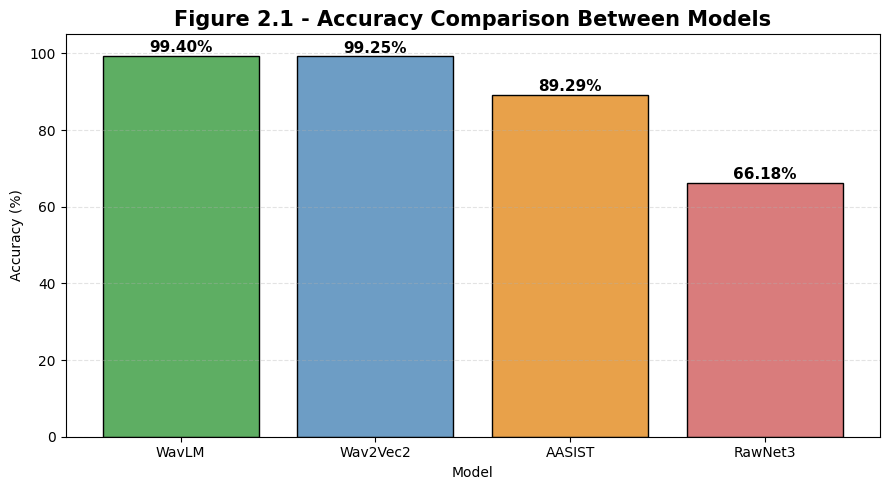

In [ ]:
plt.figure(figsize=(9, 5))

colors = [
    "#5EAE63",  # WavLM
    "#6D9DC5",  # Wav2Vec2
    "#E8A14A",  # AASIST
    "#D97C7C"   # RawNet3
]

bars = plt.bar(
    summary_df["model_display"],
    summary_df["accuracy_%"],
    color=colors,
    edgecolor="black"
)

plt.title("Figure 2.1 - Accuracy Comparison Between Models", fontsize=15, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.35)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

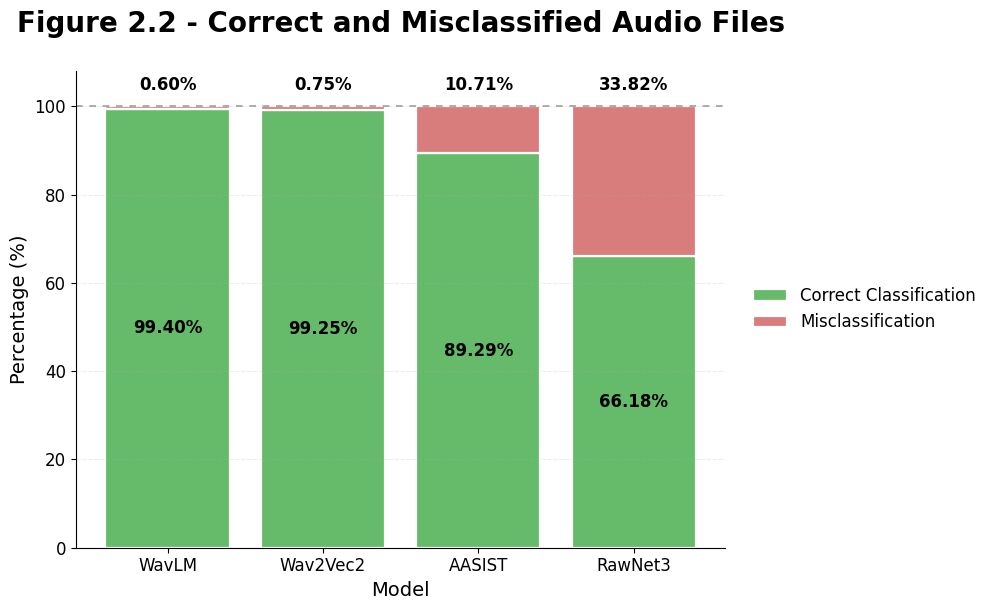

In [ ]:
# ==========================================
# Stacked Percentage Bar Chart
# Correct vs Misclassified Audio Files
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import os

BASE_PATH = "/content/drive/MyDrive/final_model_comparison/final_presentation_summary"
PLOTS_DIR = "/content/drive/MyDrive/final_model_comparison/final_comparison_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

summary_df = pd.read_csv(
    f"{BASE_PATH}/10_final_presentation_summary.csv"
)

name_map = {
    "wavlm": "WavLM",
    "wav2vec2": "Wav2Vec2",
    "aasist": "AASIST",
    "rawnet3": "RawNet3"
}

summary_df["model_display"] = summary_df["model_name"].str.lower().map(name_map)

model_order = ["WavLM", "Wav2Vec2", "AASIST", "RawNet3"]

summary_df = (
    summary_df
    .set_index("model_display")
    .loc[model_order]
    .reset_index()
)

correct = summary_df["accuracy_%"]
failed = summary_df["error_rate_%"]

correct_color = "#66BB6A"
failed_color = "#D97C7C"

plt.figure(figsize=(12, 6.2))

# Correct part
plt.bar(
    summary_df["model_display"],
    correct,
    color=correct_color,
    edgecolor="white",
    linewidth=1.6,
    label="Correct Classification"
)

# Failed part
plt.bar(
    summary_df["model_display"],
    failed,
    bottom=correct,
    color=failed_color,
    edgecolor="white",
    linewidth=1.6,
    label="Misclassification"
)

# Labels
for i in range(len(summary_df)):

    # correct percentage inside green area
    plt.text(
        i,
        correct.iloc[i] * 0.50,
        f"{correct.iloc[i]:.2f}%",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="black"
    )

    # failed percentage above the 100 line
    plt.text(
        i,
        102.8,
        f"{failed.iloc[i]:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="black"
    )

# Title and axis labels
plt.title(
    "Figure 2.2 - Correct and Misclassified Audio Files",
    fontsize=20,
    fontweight="bold",
    pad=28
)

plt.xlabel("Model", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# Leave space above 100%
plt.ylim(0, 108)

# 100% reference line
plt.axhline(
    y=100,
    color="gray",
    linestyle=(0, (4, 4)),
    linewidth=1.2,
    alpha=0.75
)

# Axis and grid styling
plt.grid(axis="y", linestyle="--", alpha=0.22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Legend outside on the right
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=12
)

# Remove top and right borders for cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.84, 1])

plt.savefig(
    f"{PLOTS_DIR}/correct_vs_failed_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

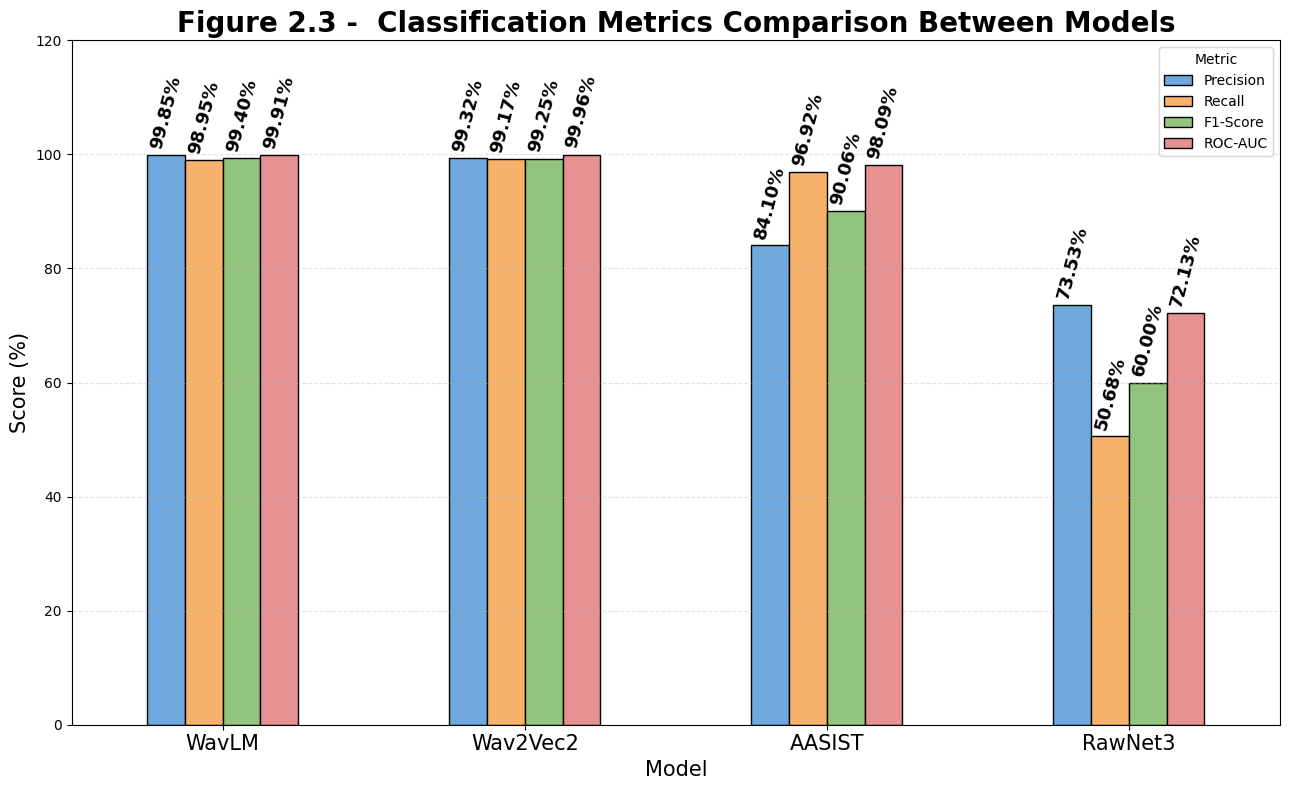

In [ ]:
metrics_plot_df = model_metrics_df.set_index("model_display")[[
    "precision_%",
    "recall_%",
    "f1_%",
    "auc_%"
]]

colors = [
    "#6FA8DC",
    "#F6B26B",
    "#93C47D",
    "#E69191"
]

ax = metrics_plot_df.plot(
    kind="bar",
    figsize=(13, 8),
    color=colors,
    edgecolor="black"
)

# הוספת מספרים אנכיים
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        rotation=75,
        padding=3,
        fontsize=13,
        fontweight="bold"

    )

plt.title("Figure 2.3 -  Classification Metrics Comparison Between Models", fontsize=20, fontweight="bold")
plt.xlabel("Model",fontsize=15)
plt.ylabel("Score (%)",fontsize=15)
plt.ylim(0, 120)
plt.xticks(rotation=0,fontsize=15)
plt.legend(["Precision", "Recall", "F1-Score", "ROC-AUC"], title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/classification_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

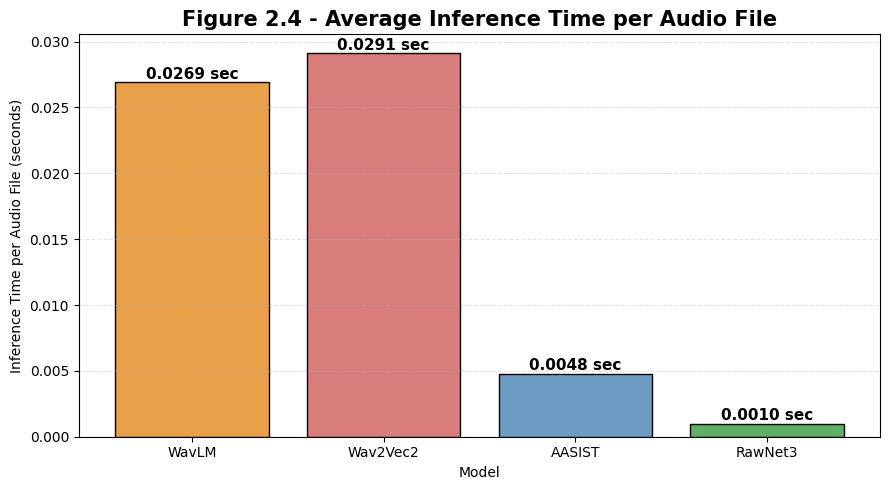

In [ ]:
plt.figure(figsize=(9, 5))

colors = [
    "#E8A14A",  # WavLM "#E8A14A"
    "#D97C7C",  # Wav2Vec2 "#D97C7C"
    "#6D9DC5",  # AASIST
    "#5EAE63"  # RawNet3 "#5EAE63"
]

bars = plt.bar(
    efficiency_df["model_display"],
    efficiency_df["avg_inference_time_per_file_sec"],
    color=colors,
    edgecolor="black"
)

plt.title("Figure 2.4 - Average Inference Time per Audio File", fontsize=15, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Inference Time per Audio File (seconds)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.0003,
        f"{height:.4f} sec",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/inference_time_per_audio_file_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

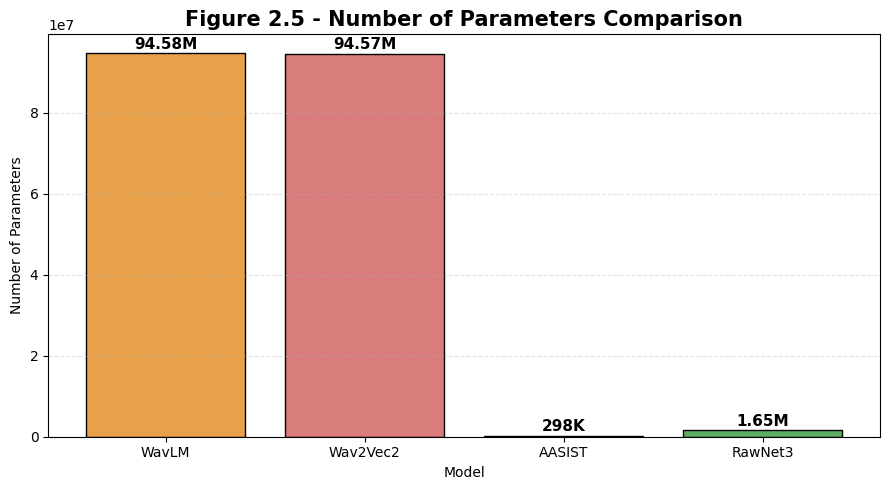

In [ ]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    efficiency_df["model_display"],
    efficiency_df["num_parameters"],
    color=colors,
    edgecolor="black"
)

plt.title("Figure 2.5 - Number of Parameters Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.grid(axis="y", linestyle="--", alpha=0.35)

for bar in bars:
    height = bar.get_height()
    if height >= 1_000_000:
        label = f"{height/1_000_000:.2f}M"
    else:
        label = f"{height/1_000:.0f}K"
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1_000_000,
        label,
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/parameters_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd
import os

BASE_PATH = "/content/drive/MyDrive/final_model_comparison/final_presentation_summary"
OUTPUT_PATH = "/content/drive/MyDrive/final_model_comparison/evaluation_tables"

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ===============================
# Load files
# ===============================

summary_df = pd.read_csv(f"{BASE_PATH}/10_final_presentation_summary.csv")
efficiency_df = pd.read_csv(f"{BASE_PATH}/09_efficiency_summary_all_models.csv")

summary_files = [
    "wavlm_summary.csv",
    "wav2vec2_summary.csv",
    "aasist_summary.csv",
    "rawnet3_summary.csv"
]

metrics_df = pd.concat(
    [pd.read_csv(f"{BASE_PATH}/{file}") for file in summary_files],
    ignore_index=True
)

# ===============================
# Normalize names
# ===============================

def normalize_model_name(name):
    name = str(name).lower()
    if "wavlm" in name:
        return "WavLM"
    if "wav2vec2" in name:
        return "Wav2Vec2"
    if "aasist" in name:
        return "AASIST"
    if "rawnet" in name:
        return "RawNet3"
    return str(name)

summary_df["model_display"] = summary_df["model_name"].apply(normalize_model_name)
efficiency_df["model_display"] = efficiency_df["model_name"].apply(normalize_model_name)
metrics_df["model_display"] = metrics_df["model_name"].apply(normalize_model_name)

model_order = ["WavLM", "Wav2Vec2", "AASIST", "RawNet3"]

In [ ]:
experiment_table = metrics_df[[
    "model_display",
    "learning_rate",
    "batch_size",
    "epochs"
]].copy()

experiment_table["fine_tuning"] = experiment_table["model_display"].map({
    "WavLM": "No additional tuning",
    "Wav2Vec2": "No additional tuning",
    "AASIST": "Epochs increased from 5 to 30",
    "RawNet3": "No additional tuning"
})

experiment_table = (
    experiment_table
    .set_index("model_display")
    .loc[model_order]
    .reset_index()
)

experiment_table.to_csv(f"{OUTPUT_PATH}/table_1_experiments_parameters.csv", index=False)
print("-" * 80)
print("Table 1.1 - Experimental Settings and Hyperparameter Configuration")
print("-" * 80)
display(experiment_table)

--------------------------------------------------------------------------------
Table 1.1 - Experimental Settings and Hyperparameter Configuration
--------------------------------------------------------------------------------


,model_display,learning_rate,batch_size,epochs,fine_tuning
0,WavLM,0.00001,4,5,No additional tuning
1,Wav2Vec2,0.00001,4,5,No additional tuning
2,AASIST,0.00010,4,30,Epochs increased from 5 to 30
3,RawNet3,0.00010,8,5,No additional tuning


In [ ]:
performance_table = summary_df[[
    "model_display",
    "total_files",
    "correct_files",
    "failed_files",
    "error_rate_%",
    "accuracy_%"
]].copy()

performance_table = (
    performance_table
    .set_index("model_display")
    .loc[model_order]
    .reset_index()
)

performance_table.to_csv(f"{OUTPUT_PATH}/table_2_final_performance.csv", index=False)
print("-" * 80)
print("Table 1.2 - Final Performance Results of the Evaluated Models")
print("-" * 80)
display(performance_table)

--------------------------------------------------------------------------------
Table 1.2 - Final Performance Results of the Evaluated Models
--------------------------------------------------------------------------------


,model_display,total_files,correct_files,failed_files,error_rate_%,accuracy_%
0,WavLM,2661,2645,16,0.60,99.40
1,Wav2Vec2,2661,2641,20,0.75,99.25
2,AASIST,2661,2376,285,10.71,89.29
3,RawNet3,2661,1761,900,33.82,66.18


In [ ]:
classification_table = metrics_df[[
    "model_display",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_auc"
]].copy()

classification_table["precision_%"] = classification_table["test_precision"] * 100
classification_table["recall_%"] = classification_table["test_recall"] * 100
classification_table["f1_%"] = classification_table["test_f1"] * 100
classification_table["auc_%"] = classification_table["test_auc"] * 100

classification_table = classification_table[[
    "model_display",
    "precision_%",
    "recall_%",
    "f1_%",
    "auc_%"
]]

classification_table = (
    classification_table
    .set_index("model_display")
    .loc[model_order]
    .reset_index()
)

classification_table.to_csv(f"{OUTPUT_PATH}/table_3_classification_metrics.csv", index=False)
print("-" * 80)
print("Table 1.3 - Classification Performance Metrics")
print("-" * 80)
display(classification_table.round(2))

--------------------------------------------------------------------------------
Table 1.3 - Classification Performance Metrics
--------------------------------------------------------------------------------


,model_display,precision_%,recall_%,f1_%,auc_%
0,WavLM,99.85,98.95,99.40,99.91
1,Wav2Vec2,99.32,99.17,99.25,99.96
2,AASIST,84.10,96.92,90.06,98.09
3,RawNet3,73.53,50.68,60.00,72.13


In [ ]:
efficiency_table = efficiency_df[[
    "model_display",
    "model_file_size_MB_os",
    "num_parameters",
    "memory_size_MB",
    "ram_used_MB",
    "peak_gpu_memory_MB",
    "avg_inference_time_per_file_sec",
    "tokens_or_frames",
    "representation_type",
    "batch_size"
]].copy()

efficiency_table = (
    efficiency_table
    .set_index("model_display")
    .loc[model_order]
    .reset_index()
)

efficiency_table.to_csv(f"{OUTPUT_PATH}/table_4_efficiency_summary.csv", index=False)
print("-" * 80)
print("Table 1.4 - Computational Efficiency Comparison")
print("-" * 80)
display(efficiency_table)

--------------------------------------------------------------------------------
Table 1.4 - Computational Efficiency Comparison
--------------------------------------------------------------------------------


,model_display,model_file_size_MB_os,num_parameters,memory_size_MB,ram_used_MB,peak_gpu_memory_MB,avg_inference_time_per_file_sec,tokens_or_frames,representation_type,batch_size
0,WavLM,360.89,94579314,360.79,563.84,679.73,0.0269,199.0,Transformer tokens,4
1,Wav2Vec2,360.84,94569090,360.75,59.77,677.18,0.0291,Not applicable,No explicit tokenization,4
2,AASIST,1.22,297866,1.14,128.77,1111.24,0.0048,Not applicable,No explicit tokenization,4
3,RawNet3,6.36,1648522,6.29,85.38,609.38,0.0010,2667.0,CNN frames after feature extraction,8


In [ ]:
ranking_table = pd.DataFrame({
    "rank": [1, 2, 3, 4],
    "model": ["WavLM", "Wav2Vec2", "AASIST", "RawNet3"],
    "accuracy_%": [99.40, 99.25, 89.29, 66.18],
    "main_strength": [
        "Highest accuracy and lowest error rate",
        "Very high accuracy, close to WavLM",
        "Improved after fine-tuning and fast inference",
        "Fastest inference but lowest detection performance"
    ],
    "final_decision": [
        "Selected for deployment",
        "Possible backup / ensemble candidate",
        "Not selected",
        "Not selected"
    ]
})

ranking_table.to_csv(f"{OUTPUT_PATH}/table_5_model_ranking_selection.csv", index=False)
print("-" * 80)
print("Table 1.5 - Final Model Ranking and Selection")
print("-" * 80)
display(ranking_table)

--------------------------------------------------------------------------------
Table 1.5 - Final Model Ranking and Selection
--------------------------------------------------------------------------------


,rank,model,accuracy_%,main_strength,final_decision
0,1,WavLM,99.40,Highest accuracy and lowest error rate,Selected for deployment
1,2,Wav2Vec2,99.25,"Very high accuracy, close to WavLM",Possible backup / ensemble candidate
2,3,AASIST,89.29,Improved after fine-tuning and fast inference,Not selected
3,4,RawNet3,66.18,Fastest inference but lowest detection perform...,Not selected
